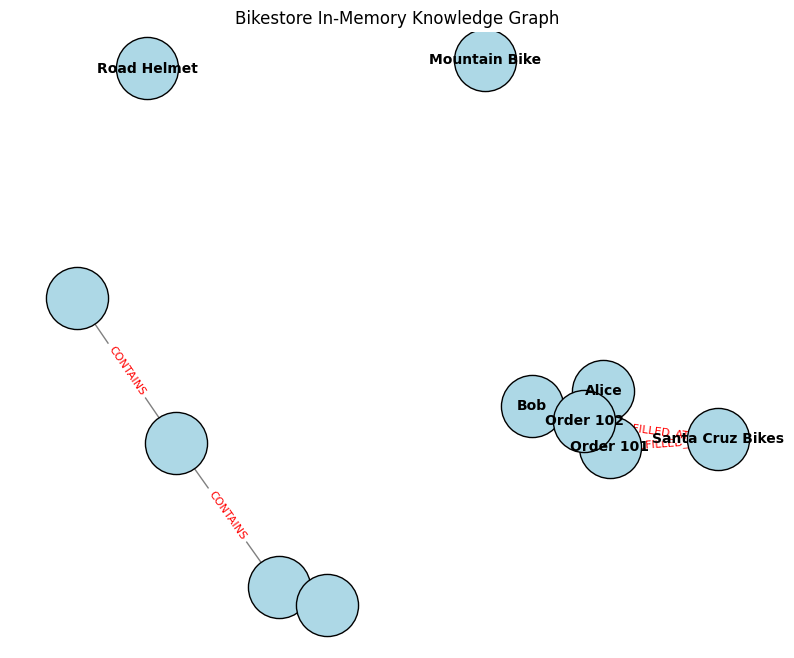

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. MOCK DATA (Simulating your SQL tables)
# ---------------------------------------------------------
customers = pd.DataFrame({
    'customer_id': [1, 2], 
    'first_name': ['Alice', 'Bob']
})

orders = pd.DataFrame({
    'order_id': [101, 102], 
    'customer_id': [1, 2], 
    'store_id': [10, 10]
})

products = pd.DataFrame({
    'product_id': [501, 502], 
    'product_name': ['Mountain Bike', 'Road Helmet']
})

order_items = pd.DataFrame({
    'order_id': [101, 101, 102], 
    'product_id': [501, 502, 502], 
    'quantity': [1, 2, 1],
    'list_price': [1200.00, 50.00, 50.00]
})

stores = pd.DataFrame({
    'store_id': [10], 
    'store_name': ['Santa Cruz Bikes']
})


# ---------------------------------------------------------
# 2. INITIALIZE THE GRAPH
# ---------------------------------------------------------
# We use a Directed Graph to show the flow of relationships
G = nx.DiGraph()


# ---------------------------------------------------------
# 3. ADD NODES (Entities)
# ---------------------------------------------------------
# Add Customers
for _, row in customers.iterrows():
    G.add_node(f"C_{row['customer_id']}", type="Customer", label=row['first_name'])

# Add Orders
for _, row in orders.iterrows():
    G.add_node(f"O_{row['order_id']}", type="Order", label=f"Order {row['order_id']}")

# Add Products
for _, row in products.iterrows():
    G.add_node(f"P_{row['product_id']}", type="Product", label=row['product_name'])

# Add Stores
for _, row in stores.iterrows():
    G.add_node(f"S_{row['store_id']}", type="Store", label=row['store_name'])


# ---------------------------------------------------------
# 4. ADD EDGES (Relationships)
# ---------------------------------------------------------
# Customer [PLACES] Order
# Order [FULFILLED_AT] Store
for _, row in orders.iterrows():
    G.add_edge(f"C_{row['customer_id']}", f"O_{row['order_id']}", relation="PLACES")
    G.add_edge(f"O_{row['order_id']}", f"S_{row['store_id']}", relation="FULFILLED_AT")

# Order [CONTAINS] Product (with properties like quantity and price)
for _, row in order_items.iterrows():
    G.add_edge(
        f"O_{row['order_id']}", 
        f"P_{row['product_id']}", 
        relation="CONTAINS", 
        qty=row['quantity'], 
        price=row['list_price']
    )


# ---------------------------------------------------------
# 5. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Choose a layout for the nodes
pos = nx.spring_layout(G, seed=42) 

# Extract node labels to display
node_labels = nx.get_node_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'relation')

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black')

# Draw Edges
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, edge_color='gray')

# Draw Labels
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='red')

plt.title("Bikestore In-Memory Knowledge Graph")
plt.axis('off') # Turn off the axes
plt.show()

In [3]:
import os
import vertexai
from vertexai import rag
from vertexai.generative_models import GenerativeModel, Tool

# --- Configuration ---
PROJECT_ID = "gdc-ai-testing"
LOCATION = "us-central1" # Ensure this matches your project's active region
GCS_URI = "gs://database-doc-bucket/schema_analysis_bikestore_1771702471.json"
DISPLAY_NAME = "database-dictionary-corpus"

def test_rag_pipeline():
    print("1. Initializing Vertex AI...")
    vertexai.init(project=PROJECT_ID, location=LOCATION)

    print("2. Configuring embedding model...")
    embedding_model_config = rag.RagEmbeddingModelConfig(
        vertex_prediction_endpoint=rag.VertexPredictionEndpoint(
            publisher_model="publishers/google/models/text-embedding-005"
        )
    )

    print("3. Creating RAG Corpus...")
    rag_corpus = rag.create_corpus(
        display_name=DISPLAY_NAME,
        backend_config=rag.RagVectorDbConfig(
            rag_embedding_model_config=embedding_model_config
        ),
    )
    print(f"✅ Corpus created! ID: {rag_corpus.name}")

    print(f"4. Importing {GCS_URI} into corpus...")
    response = rag.import_files(
        rag_corpus.name,
        [GCS_URI],
        transformation_config=rag.TransformationConfig(
            chunking_config=rag.ChunkingConfig(
                chunk_size=512,
                chunk_overlap=100,
            ),
        ),
        max_embedding_requests_per_min=1000,
    )
    print(f"✅ Import complete! {response.imported_files_count} files imported.")

    print("\n--- Testing Retrieval & Chat ---")
    
    # --- Test 1: Direct Context Retrieval ---
    # This proves the database can find relevant text based on meaning
    print("5. Testing Direct Context Retrieval...")
    rag_retrieval_config = rag.RagRetrievalConfig(
        top_k=3,
        filter=rag.Filter(vector_distance_threshold=0.5),
    )
    
    test_query = "What tables exist in the bikestore schema?"
    retrieval_response = rag.retrieval_query(
        rag_resources=[
            rag.RagResource(rag_corpus=rag_corpus.name)
        ],
        text=test_query,
        rag_retrieval_config=rag_retrieval_config,
    )
    print("\n🔍 Raw Retrieval Results:")
    print(retrieval_response)

    # --- Test 2: Chatting with Gemini ---
    # This proves Gemini can read the retrieved context and answer gracefully
    print("\n6. Testing Chat with Gemini 2.0 Flash...")
    rag_retrieval_tool = Tool.from_retrieval(
        retrieval=rag.Retrieval(
            source=rag.VertexRagStore(
                rag_resources=[
                    rag.RagResource(rag_corpus=rag_corpus.name)
                ],
                rag_retrieval_config=rag_retrieval_config,
            ),
        )
    )

    rag_model = GenerativeModel(
        model_name="gemini-2.5-flash", 
        tools=[rag_retrieval_tool]
    )

    chat_response = rag_model.generate_content(test_query)
    print("\n🤖 Gemini Response:")
    print(chat_response.text)
    
    print(f"\n🚀 ALL TESTS PASSED. Save this corpus ID for your backend:\n{rag_corpus.name}")

# if __name__ == "__main__":
test_rag_pipeline()

1. Initializing Vertex AI...
2. Configuring embedding model...
3. Creating RAG Corpus...


RuntimeError: ('Failed in RagCorpus creation due to: ', PermissionDenied("Permission 'aiplatform.ragCorpora.create' denied on resource '//aiplatform.googleapis.com/projects/gdc-ai-testing/locations/us-central1' (or it may not exist)."))

In [ ]:
import kagglehub
import shutil
import os

# Download dataset
# path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
path = kagglehub.dataset_download("dillonmyrick/bike-store-sample-database")
# 

print("Downloaded to:", path)

# Copy to simple location
target = r"~/bikestore-data"

if not os.path.exists(target):
    os.makedirs(target)

# Copy files
for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), target)

print("Copied to:", target)
